In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, precision_recall_curve, roc_curve, roc_auc_score, classification_report

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv')

In [3]:
# Define which columns are numerical
num_cols_to_fill = ['transaction_amount', 'time_day', 'time_diff_log']

# Fill numerical columns with median
for col in num_cols_to_fill:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# For categorical columns: convert NaN to string 'nan' so it acts as a category
cat_cols_to_fill = [col for col in df.columns if col not in num_cols_to_fill]
for col in cat_cols_to_fill:
    df[col] = df[col].astype(str)  # This converts NaN to string 'nan'

In [4]:
label = df['is_fraud']
predictors = df.drop(columns=['is_fraud']) 
x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [5]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64
is_fraud
0    0.964986
1    0.035014
Name: proportion, dtype: float64


In [6]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_amount       471129 non-null  float64
 1   card_type                471129 non-null  object 
 2   purchaser_email_domain   471129 non-null  object 
 3   device_type              471129 non-null  object 
 4   is_identity_seen_before  471129 non-null  object 
 5   user_os                  471129 non-null  object 
 6   user_browser             471129 non-null  object 
 7   environment_risk         471129 non-null  object 
 8   card_info                471129 non-null  object 
 9   time_hour                471129 non-null  object 
 10  time_day                 471129 non-null  float64
 11  amt_bins                 471129 non-null  object 
 12  day_of_week              471129 non-null  object 
 13  time_diff_log            471129 non-null  float64
dtypes: fl

In [7]:
num_cols = ['transaction_amount', 'time_day', 'time_diff_log']
cat_cols = [col for col in x_train.columns if col not in num_cols]

In [8]:
# def to_str_func(x):
#     return x.astype(str)

# def log_transform(x):
#     return np.log1p(x.astype(float))

# num_pipeline = Pipeline([
#     ('log', FunctionTransformer(log_transform, validate=False)),
#     ('scaler', StandardScaler())
# ])

# cat_pipeline = Pipeline([
#     ('to_str', FunctionTransformer(to_str_func)),
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer([
#     ('num', num_pipeline, num_cols),
#     ('cat', cat_pipeline, cat_cols)
# ])

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', RandomForestClassifier(class_weight='balanced'))
# ])

# final_pipe.fit(x_train, y_train)


# base_model = final_pipe

In [9]:
def log_transform(x):
    return np.log1p(x.astype(float))

def to_str_func(x):
    return x.astype(str)

model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/Model_v2.pkl')
cv_predict = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_predict_v2.pkl')

In [10]:
cm = confusion_matrix(y_train, cv_predict)
cm

array([[454185,    446],
       [ 13087,   3411]])

In [11]:
print(precision_score(y_train, cv_predict , pos_label='1' ) * 100)
print(recall_score(y_train, cv_predict, pos_label= '1') * 100)

88.43660876328752
20.67523336161959


In [12]:
print(classification_report(y_train, cv_predict, ))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    454631
           1       0.88      0.21      0.34     16498

    accuracy                           0.97    471129
   macro avg       0.93      0.60      0.66    471129
weighted avg       0.97      0.97      0.96    471129



In [13]:
cv_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_proba_v2.pkl')

In [14]:
precision, recall, threshold = precision_recall_curve(y_train, cv_proba, pos_label='1')

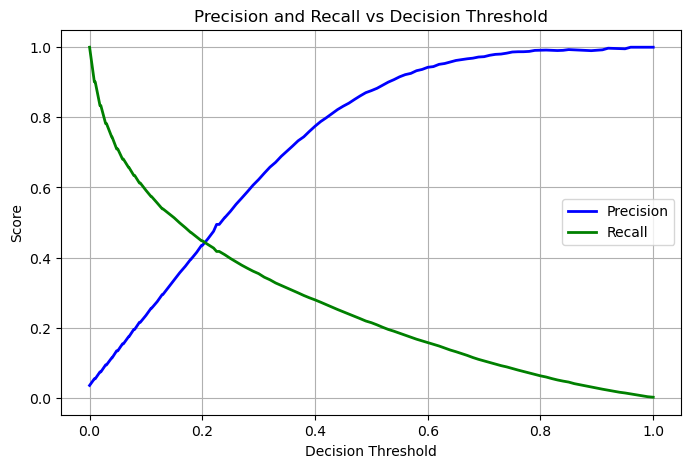

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Precision vs threshold
plt.plot(threshold, precision[:-1], "b-", linewidth=2, label="Precision")

# Recall vs threshold
plt.plot(threshold, recall[:-1], "g-", linewidth=2, label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
y_pred = (cv_proba>= 0.1775).astype(int)
y_train = y_train.astype(int)

In [17]:
print(precision_score(y_train, y_pred  ) * 100)
print(recall_score(y_train, y_pred) * 100)

39.513260847474854
47.139047157231175


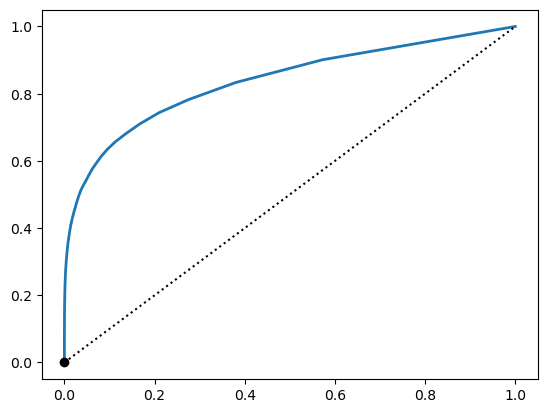

In [18]:
fpr, tpr , thresholds = roc_curve(y_train, cv_proba)
plt.plot(fpr, tpr, linewidth=2 , label= "Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
idx_for_threshold = (threshold <= 0.1775 ).argmax()
tpr_10 = tpr[idx_for_threshold]
fpr_10 = fpr[idx_for_threshold]
plt.plot([fpr_10], [tpr_10], "ko", label="Threshold for 90% precision")

In [19]:
roc_auc_score(y_train, cv_proba)

np.float64(0.8363967762341196)

In [20]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_amount       471129 non-null  float64
 1   card_type                471129 non-null  object 
 2   purchaser_email_domain   471129 non-null  object 
 3   device_type              471129 non-null  object 
 4   is_identity_seen_before  471129 non-null  object 
 5   user_os                  471129 non-null  object 
 6   user_browser             471129 non-null  object 
 7   environment_risk         471129 non-null  object 
 8   card_info                471129 non-null  object 
 9   time_hour                471129 non-null  object 
 10  time_day                 471129 non-null  float64
 11  amt_bins                 471129 non-null  object 
 12  day_of_week              471129 non-null  object 
 13  time_diff_log            471129 non-null  float64
dtypes: fl

In [21]:
fraud_probs = model.predict_proba(x_train)[y_train == 1, 1]
nonfraud_probs = model.predict_proba(x_train)[y_train == 0, 1]

ValueError: columns are missing: {'card_network'}

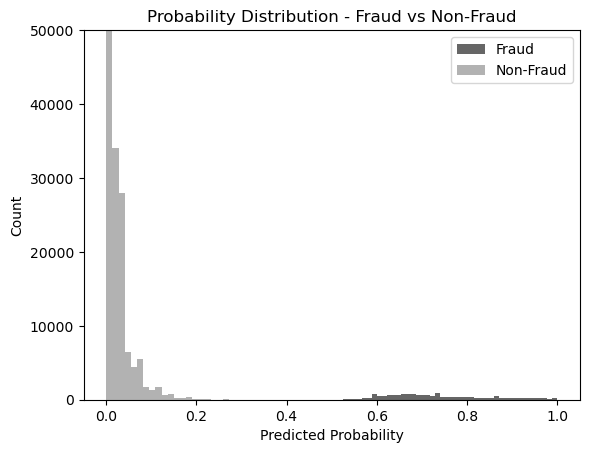

In [ ]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 50000)
plt.show()

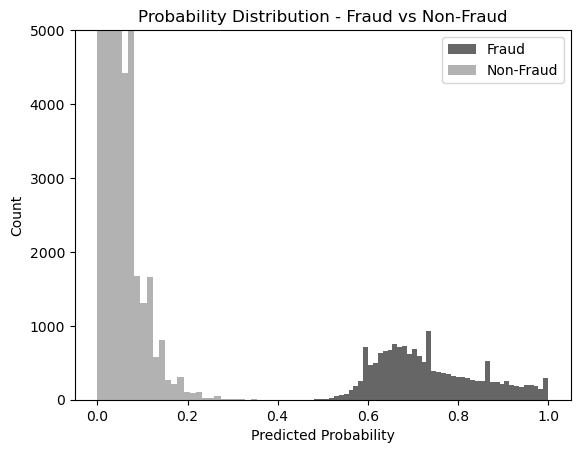

In [ ]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 5000)
plt.show()

In [ ]:
print(f"Fraud Mean:      {fraud_probs.mean():.4f}")
print(f"Non-Fraud Mean:  {nonfraud_probs.mean():.4f}")
print(f"Gap:             {(fraud_probs.mean() - nonfraud_probs.mean()):.4f}")
print(f"Fraud Max:       {fraud_probs.max():.4f}")
print(f"Non Fraud mean: {nonfraud_probs.max():.4f}")
print(f"Fraud Std:         {fraud_probs.std():.4f}")
print(f"Non-Fraud Std:     {nonfraud_probs.std():.4f}")

Fraud Mean:      0.7359
Non-Fraud Mean:  0.0096
Gap:             0.7264
Fraud Max:       1.0000
Non Fraud mean: 0.6831
Fraud Std:         0.1128
Non-Fraud Std:     0.0209


In [ ]:
# Get cat feature names manually
cat_features = model.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .named_steps['onehot']\
                .get_feature_names_out(cat_cols).tolist()

# Combine num + cat
all_features = list(num_cols) + cat_features

# Now get feature importance
feat_imp = pd.Series(
    model.named_steps['model'].feature_importances_,
    index=all_features
).sort_values(ascending=False)

for feat, score in feat_imp.items():
    print(f"{feat}: {score:.4f}")

time_day: 0.1595
transaction_amount: 0.1176
time_diff_log: 0.1111
user_os_Other: 0.0245
purchaser_email_domain_gmail.com: 0.0175
device_type_nan: 0.0170
day_of_week_1: 0.0140
card_type_debit: 0.0139
day_of_week_4: 0.0131
day_of_week_6: 0.0130
day_of_week_0: 0.0129
day_of_week_2: 0.0128
card_type_credit: 0.0127
environment_risk_0.0: 0.0126
day_of_week_5: 0.0124
day_of_week_3: 0.0120
purchaser_email_domain_nan: 0.0113
purchaser_email_domain_yahoo.com: 0.0111
user_os_nan: 0.0103
user_browser_nan: 0.0102
time_hour_21: 0.0098
time_hour_18: 0.0098
time_hour_19: 0.0097
time_hour_20: 0.0096
user_browser_Chrome: 0.0095
is_identity_seen_before_Found: 0.0095
time_hour_23: 0.0094
is_identity_seen_before_nan: 0.0094
environment_risk_nan: 0.0094
time_hour_22: 0.0093
time_hour_17: 0.0092
time_hour_16: 0.0091
device_type_mobile: 0.0087
amt_bins_9: 0.0086
purchaser_email_domain_anonymous.com: 0.0086
time_hour_0: 0.0086
time_hour_15: 0.0081
purchaser_email_domain_hotmail.com: 0.0079
time_hour_1: 0.0076


In [ ]:
# Create feature groups
feat_groups = {
    'time_hour': feat_imp.filter(like='time_hour').sum(),
    'day_of_week': feat_imp.filter(like='day_of_week').sum(),
    'amt_bins': feat_imp.filter(like='amt_bins').sum(),
    'user_os': feat_imp.filter(like='user_os').sum(),
    'device_type': feat_imp.filter(like='device_type').sum(),
    'user_browser': feat_imp.filter(like='user_browser').sum(),
    'card_network': feat_imp.filter(like='card_network').sum(),
    'card_type': feat_imp.filter(like='card_type').sum(),
    'card_info': feat_imp.filter(like='card_info').sum(),
    'email_domain': feat_imp.filter(like='purchaser_email_domain').sum(),
    'identity': feat_imp.filter(like='is_identity').sum(),
    'environment_risk': feat_imp.filter(like='environment_risk').sum(),
    'time_day': feat_imp.filter(like='time_day').sum(),
    'time_diff_log': feat_imp.filter(like='time_diff_log').sum(),
    'transaction_amount': feat_imp.filter(like='transaction_amount').sum(),
}

group_imp = pd.Series(feat_groups).sort_values(ascending=False)
print(group_imp)

time_day              0.159466
time_hour             0.151905
transaction_amount    0.117568
time_diff_log         0.111095
day_of_week           0.090208
email_domain          0.089172
amt_bins              0.061406
user_os               0.046102
device_type           0.030828
user_browser          0.029771
card_type             0.026551
environment_risk      0.026371
identity              0.024733
card_info             0.023133
card_network          0.011692
dtype: float64


In [ ]:
df = df.drop(columns=['Unnamed: 0'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  object 
 1   transaction_amount       588912 non-null  float64
 2   card_type                588912 non-null  object 
 3   purchaser_email_domain   588912 non-null  object 
 4   device_type              588912 non-null  object 
 5   is_identity_seen_before  588912 non-null  object 
 6   user_os                  588912 non-null  object 
 7   user_browser             588912 non-null  object 
 8   environment_risk         588912 non-null  object 
 9   card_info                588912 non-null  object 
 10  time_hour                588912 non-null  object 
 11  time_day                 588912 non-null  float64
 12  amt_bins                 588912 non-null  object 
 13  day_of_week              588912 non-null  object 
 14  time

In [ ]:
df.to_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv', index=False)

In [ ]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  int64  
 1   transaction_amount       588912 non-null  float64
 2   card_type                588912 non-null  object 
 3   purchaser_email_domain   494686 non-null  object 
 4   device_type              140606 non-null  object 
 5   is_identity_seen_before  129173 non-null  object 
 6   user_os                  144028 non-null  object 
 7   user_browser             144028 non-null  object 
 8   environment_risk         144028 non-null  float64
 9   card_info                588912 non-null  object 
 10  time_hour                588912 non-null  int64  
 11  time_day                 588912 non-null  float64
 12  amt_bins                 588912 non-null  int64  
 13  day_of_week              588912 non-null  int64  
 14  time